# 38 — Tier 1: Does one-sided messaging move opinion, and is the effect trustworthy?

**Companion to [NB 37 (calibration)](37_tierP_calibration.ipynb).** NB 37 showed the raw model
is *inflated in level* (it likes climate policy a bit too much) but *faithful in rank* (it puts
the right people in the right order). Because of that, every simulated citizen starts **Day 0
pinned to their real YouGov opinion** (the "ground-truth anchor"). This notebook asks the
scientific question the whole project is built around:

> **When one political side gets to broadcast more loudly than the other, do citizens' opinions
> actually move in the expected direction — and can we trust that movement, given the model's
> known pro-climate lean?**

## The experiment in one picture

Every citizen hears two political voices over five simulated days:

* **Voice A — the "Green" side** (pro-climate broadcasts).
* **Voice B — the "Reform" side** (anti-/sceptical broadcasts).

We ran the **same 100 citizens** (identical people, identical starting opinions) through **four
different worlds**, and repeated the whole thing for **three random draws of citizens** (seeds
42, 43, 44) so nothing hinges on one lucky sample:

| Condition | What changes | What we expect |
| --- | --- | --- |
| **Baseline** | Both sides reach everyone equally | Little net movement |
| **Green-dominant** | Green reaches everyone, Reform throttled to 25% | Opinion drifts **more pro-climate** |
| **Reform-dominant** | Reform reaches everyone, Green throttled to 25% | Opinion drifts **less pro-climate** |
| **Neither (placebo)** | *No broadcasts at all* | Whatever the pipeline does with no persuasion |

Because it is the **same people** in every world, we can compare worlds *citizen-by-citizen* — the
cleanest kind of comparison there is. The **Neither** world is our placebo: it tells us how much
opinion drifts for reasons that have nothing to do with the broadcasts.

## What "success" looks like

1. Green-dominant ends **more** pro-climate than Reform-dominant (a clear, correctly-signed gap).
2. The gap is **statistically real** (unlikely to be chance) and **not trivially small**.
3. The gap is **not just the model's pro-climate bias leaking through** — we prove this with the
   placebo and with a direct "does-the-effect-depend-on-where-you-started" test.

Every metric below is defined in plain English the first time it appears.


## 1. Setup

In [1]:
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

EXP_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "experiments"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "tier1_analysis"))
os.makedirs(FIG_DIR, exist_ok=True)

# Condition display order, labels, colours.
COND_ORDER = ["baseline", "green_dom", "reform_dom", "neither"]
COND_LABEL = {
    "baseline":   "Baseline (equal reach)",
    "green_dom":  "Green-dominant",
    "reform_dom": "Reform-dominant",
    "neither":    "Neither (placebo)",
}
COND_COLOR = {
    "baseline":   "#636363",   # grey
    "green_dom":  "#2ca25f",   # green
    "reform_dom": "#8856a7",   # purple
    "neither":    "#bdbdbd",   # light grey
}
GT_COLOR = "#111111"
SEEDS = [42, 43, 44]

print("Experiments dir:", EXP_DIR)
print("Figures ->     :", FIG_DIR)

Experiments dir: /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/experiments
Figures ->     : /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/tier1_analysis


In [2]:
def discover_runs(exp_dir):
    "Parse condition + seed out of each run_6458*_tier1_<cond>_s<seed> folder."
    pat = re.compile(r"run_(\d+)_tier1_(baseline|green_dom|reform_dom|neither)_s(\d+)$")
    rows = []
    for run_dir in sorted(glob.glob(os.path.join(exp_dir, "run_6458*_tier1_*"))):
        m = pat.search(os.path.basename(run_dir))
        if not m:
            continue
        subs = sorted(p for p in glob.glob(os.path.join(run_dir, "*")) if os.path.isdir(p))
        rows.append({"jobid": int(m.group(1)), "condition": m.group(2),
                     "seed": int(m.group(3)), "sub": subs[0],
                     "run": os.path.basename(run_dir)})
    df = pd.DataFrame(rows)
    df["condition"] = pd.Categorical(df["condition"], COND_ORDER, ordered=True)
    return df.sort_values(["condition", "seed"]).reset_index(drop=True)


def load_pkg(sub):
    "One run -> per-(agent, day) package index, with each agent's ground truth attached."
    traj = pd.read_csv(os.path.join(sub, "package_index_trajectories.csv"))
    traj = traj[["agent_id", "day", "package_index"]].rename(columns={"package_index": "index"})
    gt = pd.read_csv(os.path.join(sub, "package_ground_truth.csv"))[["agent_id", "ground_truth"]]
    gt = gt.rename(columns={"ground_truth": "gt"})
    out = traj.merge(gt, on="agent_id")
    out["agent_id"] = out["agent_id"].astype(int)
    return out


runs = discover_runs(EXP_DIR)
assert len(runs) == 12, f"expected 12 Tier-1 runs, found {len(runs)}"
parts = []
for _, r in runs.iterrows():
    p = load_pkg(r["sub"])
    p.insert(0, "seed", r["seed"])
    p.insert(0, "condition", r["condition"])
    parts.append(p)
T = pd.concat(parts, ignore_index=True)
T["condition"] = pd.Categorical(T["condition"], COND_ORDER, ordered=True)

DAY_END = int(T["day"].max())
print(f"Loaded {len(T):,} (agent, day) rows across {len(runs)} runs.")
print(f"Days present: {sorted(T['day'].unique())}  ->  end-of-run day = {DAY_END}")
runs[["jobid", "condition", "seed", "run"]]

Loaded 7,200 (agent, day) rows across 12 runs.
Days present: [0, 1, 2, 3, 4, 5]  ->  end-of-run day = 5


,jobid,condition,seed,run
0,6458324,baseline,42,run_6458324_tier1_baseline_s42
1,6458325,baseline,43,run_6458325_tier1_baseline_s43
2,6458326,baseline,44,run_6458326_tier1_baseline_s44
3,6458327,green_dom,42,run_6458327_tier1_green_dom_s42
4,6458328,green_dom,43,run_6458328_tier1_green_dom_s43
5,6458329,green_dom,44,run_6458329_tier1_green_dom_s44
6,6458330,reform_dom,42,run_6458330_tier1_reform_dom_s42
7,6458331,reform_dom,43,run_6458331_tier1_reform_dom_s43
8,6458332,reform_dom,44,run_6458332_tier1_reform_dom_s44
9,6458333,neither,42,run_6458333_tier1_neither_s42


### 1a. Sanity check — everyone really does start pinned to reality

Our whole design leans on one fact: on **Day 0**, every citizen's simulated opinion equals their
**real** YouGov opinion (the "ground-truth anchor"). Let's confirm it. If the largest Day-0
mismatch is essentially zero, the anchor is doing its job and all four worlds start from the exact
same place — which is what makes the citizen-by-citizen comparison fair.


In [3]:
day0 = T[T["day"] == 0]
anchor_gap = (day0["index"] - day0["gt"]).abs().max()
print(f"Largest Day-0 gap between simulated opinion and real YouGov opinion: {anchor_gap:.6f}")
print("-> Day 0 = ground truth, exactly. Every condition starts from the same anchored opinions.\n")

# Also confirm the same 100 citizens appear in all four worlds, per seed.
for s in SEEDS:
    sets = {c: set(T[(T.seed == s) & (T.condition == c)]["agent_id"]) for c in COND_ORDER}
    common = set.intersection(*sets.values())
    print(f"seed {s}: {len(common)} citizens shared across all four conditions "
          f"(sizes: {[len(sets[c]) for c in COND_ORDER]})")

Largest Day-0 gap between simulated opinion and real YouGov opinion: 0.000000
-> Day 0 = ground truth, exactly. Every condition starts from the same anchored opinions.

seed 42: 100 citizens shared across all four conditions (sizes: [100, 100, 100, 100])
seed 43: 100 citizens shared across all four conditions (sizes: [100, 100, 100, 100])
seed 44: 100 citizens shared across all four conditions (sizes: [100, 100, 100, 100])


## 2. The metrics, in plain English

You do **not** need a statistics background to read this notebook. Here is every term we use.

* **Package index** — one number summarising how pro-climate a citizen is, averaging their stance
  on all six climate policies. Scale runs from about **−3** (strongly against) through **0**
  (neutral) to **+3** (strongly in favour). Higher = greener.

* **Ground truth** — the citizen's *real* opinion, taken from the YouGov survey. This is the
  yardstick everything is measured against.

* **Opinion shift (Δ)** — how far a citizen moved over the five days: their end-of-run index minus
  their Day-0 index. Positive = became greener; negative = became more sceptical. Because Day 0 is
  pinned to ground truth, the shift is literally "how far the simulation pulled them away from
  their real opinion."

* **Mean & 95% confidence interval (CI)** — the average across citizens, plus the range we're 95%
  confident the true average lies in. If a CI does **not** cross zero, the effect is statistically
  present. Nature-style reporting prefers CIs over bare "significant / not significant".

* **Difference-in-Differences (DiD)** — the star of the show; explained in full in Section 4.
  In one line: it is the *difference between two groups' shifts*, and it cancels out anything the
  groups have in common (including the model's baseline pro-climate lean).

* **p-value (paired t-test)** — the probability of seeing a gap this large by pure chance if there
  were really no effect. Small (conventionally < 0.05) = unlikely to be a fluke. "Paired" because
  we compare the **same** citizen across two worlds.

* **Cohen's d (effect size)** — *how big* the effect is, in standard-deviation units, independent
  of sample size. Rough guide: **0.2 small, 0.5 medium, 0.8 large.** A tiny p-value with a tiny d
  means "real but trivial"; we want both a small p *and* a respectable d.

* **Placebo (Neither)** — the no-broadcast world. Any movement here is *not* caused by persuasion,
  so it is the baseline drift we must beat.

* **Spearman rank correlation (ρ)** — does the simulation keep citizens in the **right order**
  (greenest still greenest, most sceptical still most sceptical) relative to their real opinions?
  Ranges −1 to +1; near +1 means the ordering of people is faithfully preserved.


## 3. The picture — where each world ends up

We plot the **average package index of all 300 citizens** (100 per seed × 3 seeds) on each day,
one line per world, with a shaded 95% confidence band. The black dashed line is the shared Day-0
starting point (= real YouGov average). The gap that opens up between **Green-dominant** and
**Reform-dominant** is the headline effect.


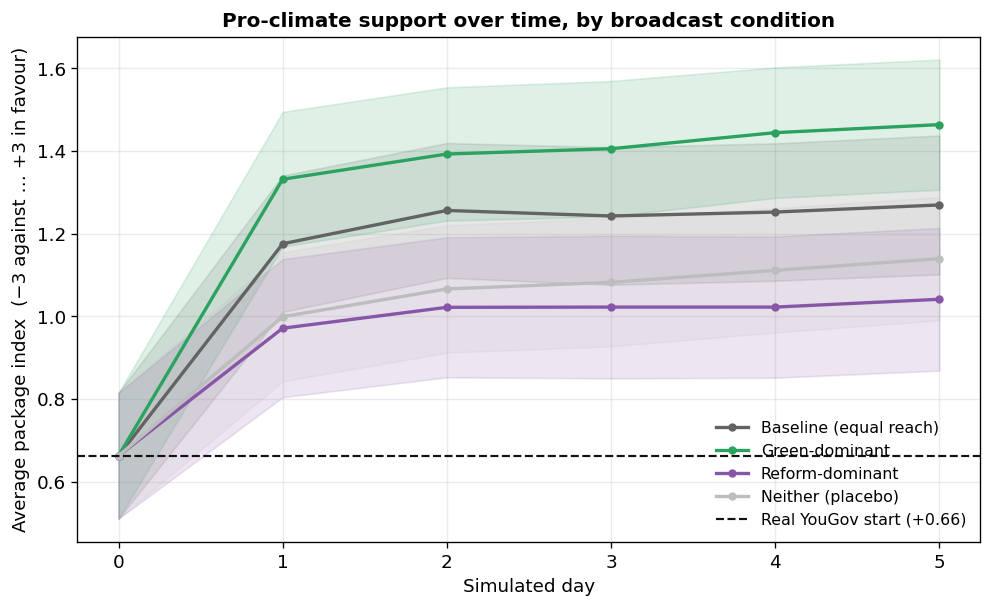

Saved fig1_trajectories.png


In [4]:
def mean_ci(x, conf=0.95):
    x = np.asarray(x, float)
    n = len(x); m = x.mean()
    if n < 2:
        return m, m, m
    sem = x.std(ddof=1) / np.sqrt(n)
    h = stats.t.ppf(0.5 + conf / 2, n - 1) * sem
    return m, m - h, m + h

# Per-(condition, day) mean and 95% band, pooled over the three seeds.
rows = []
for c in COND_ORDER:
    for d in sorted(T["day"].unique()):
        vals = T[(T.condition == c) & (T.day == d)]["index"]
        m, lo, hi = mean_ci(vals)
        rows.append({"condition": c, "day": d, "mean": m, "lo": lo, "hi": hi})
traj = pd.DataFrame(rows)

gt_start = T[T.day == 0]["gt"].mean()

fig, ax = plt.subplots(figsize=(8.4, 5.2))
for c in COND_ORDER:
    sub = traj[traj.condition == c]
    ax.plot(sub["day"], sub["mean"], "-o", color=COND_COLOR[c], label=COND_LABEL[c], lw=2, ms=4)
    ax.fill_between(sub["day"], sub["lo"], sub["hi"], color=COND_COLOR[c], alpha=0.15)
ax.axhline(gt_start, color=GT_COLOR, ls="--", lw=1.3, label=f"Real YouGov start ({gt_start:+.2f})")
ax.set_xlabel("Simulated day")
ax.set_ylabel("Average package index  (−3 against … +3 in favour)")
ax.set_title("Pro-climate support over time, by broadcast condition")
ax.legend(frameon=False, fontsize=9.5)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig1_trajectories.png"), bbox_inches="tight")
plt.show()
print("Saved fig1_trajectories.png")

### 3a. Where each world started and ended

The table below is the plain summary: average Day-0 index (identical everywhere — the anchor),
average end index, and the **opinion shift** (end − start) with its 95% confidence interval.
Read the **shift** column: positive means the world pushed citizens greener than reality; negative
means more sceptical.


In [5]:
end = T[T.day == DAY_END][["condition", "seed", "agent_id", "index", "gt"]].rename(columns={"index": "end"})
start = T[T.day == 0][["condition", "seed", "agent_id", "index"]].rename(columns={"index": "start"})
S = end.merge(start, on=["condition", "seed", "agent_id"])
S["shift"] = S["end"] - S["start"]

rows = []
for c in COND_ORDER:
    sc = S[S.condition == c]
    m, lo, hi = mean_ci(sc["shift"])
    rows.append({"condition": COND_LABEL[c], "n": len(sc),
                 "mean start": sc["start"].mean(), "mean end": sc["end"].mean(),
                 "shift": m, "shift 95% CI": f"[{lo:+.3f}, {hi:+.3f}]"})
summary = pd.DataFrame(rows).set_index("condition")
summary.round(3)

,n,mean start,mean end,shift,shift 95% CI
condition,,,,,
Baseline (equal reach),300,0.662,1.269,0.607,"[+0.515, +0.699]"
Green-dominant,300,0.662,1.464,0.802,"[+0.699, +0.905]"
Reform-dominant,300,0.662,1.041,0.379,"[+0.292, +0.466]"
Neither (placebo),300,0.662,1.139,0.477,"[+0.400, +0.554]"


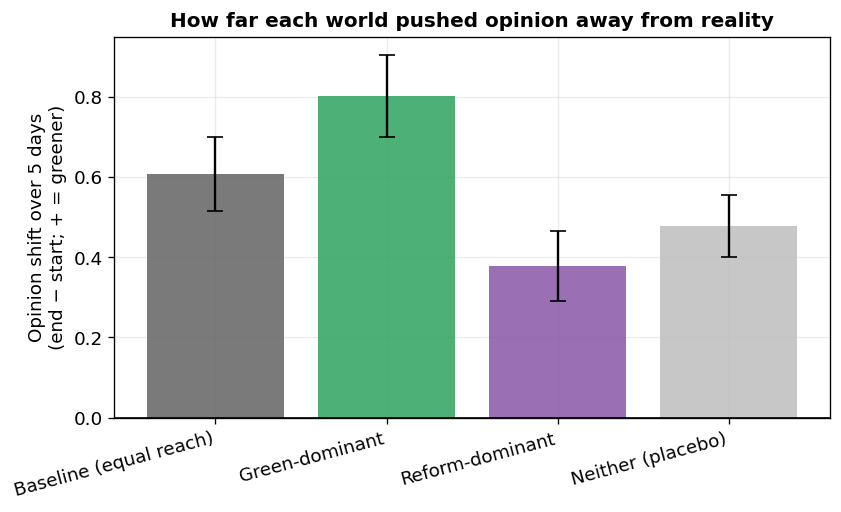

Saved fig2_shift_by_condition.png


In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
xs = np.arange(len(COND_ORDER))
for i, c in enumerate(COND_ORDER):
    sc = S[S.condition == c]["shift"]
    m, lo, hi = mean_ci(sc)
    ax.bar(i, m, color=COND_COLOR[c], alpha=0.85)
    ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=5, lw=1.4)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(xs); ax.set_xticklabels([COND_LABEL[c] for c in COND_ORDER], rotation=15, ha="right")
ax.set_ylabel("Opinion shift over 5 days\n(end − start; + = greener)")
ax.set_title("How far each world pushed opinion away from reality")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_shift_by_condition.png"), bbox_inches="tight")
plt.show()
print("Saved fig2_shift_by_condition.png")

## 4. Difference-in-Differences (DiD) — the heart of the analysis

**The problem it solves.** NB 37 showed the model is a bit too green *on average*. So if
Green-dominant citizens end up greener than they started, a sceptic could object: "That's just the
model's built-in pro-climate lean, not real persuasion." DiD answers that objection cleanly.

**The idea.** Instead of asking "did opinion move?", we ask "did opinion move **more** in one world
than in another?" — and we take a **difference of two differences**:

1. *First difference:* each world's opinion shift (end − start). This already removes each
   citizen's own starting point.
2. *Second difference:* subtract one world's shift from another's. This removes **everything the
   two worlds share** — including the model's baseline pro-climate lean, which is present in both.

Whatever is left is caused only by the thing that actually differed between the two worlds: **which
side got to broadcast more loudly.**

**Why it is especially clean here.** Every citizen starts Day 0 at the *same* anchored value in
every world (we verified this in §1a). So for a single citizen:

$$\text{DiD} = \underbrace{(\text{end}_{\text{green}} - \text{start})}_{\text{shift in Green world}}
 - \underbrace{(\text{end}_{\text{reform}} - \text{start})}_{\text{shift in Reform world}}
 = \text{end}_{\text{green}} - \text{end}_{\text{reform}}.$$

The shared start (which *is* the model's ground-truth-anchored, bias-free number) **cancels
algebraically**. There is no way for the anchor — or any common bias — to drive this contrast. We
compute it as a proper difference-of-shifts anyway (so the logic is transparent), and report:

* **DiD** — the average gap, in index points.
* **95% CI** — the plausible range; if it excludes 0, the gap is statistically real.
* **paired p-value** — chance of a gap this big if there were truly no difference.
* **Cohen's d** — how big the gap is in standardised units.

We compare the **same citizens** across worlds (matched on seed + citizen id), pooling all
300 matched citizens.


In [7]:
def did(c1, c2):
    "Paired difference-of-shifts between two conditions, matched citizen-by-citizen."
    a = S[S.condition == c1][["seed", "agent_id", "shift", "gt"]].rename(columns={"shift": "s1"})
    b = S[S.condition == c2][["seed", "agent_id", "shift"]].rename(columns={"shift": "s2"})
    m = a.merge(b, on=["seed", "agent_id"])
    d = (m["s1"] - m["s2"]).to_numpy()
    mean, lo, hi = mean_ci(d)
    # paired t-test (same as one-sample t-test on the per-citizen differences).
    t, p = stats.ttest_rel(m["s1"], m["s2"])
    dz = d.mean() / d.std(ddof=1)          # Cohen's d for paired data
    return {"contrast": f"{COND_LABEL[c1]}  −  {COND_LABEL[c2]}", "n_pairs": len(d),
            "DiD": mean, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
            "p_value": p, "Cohen_d": dz, "_lo": lo, "_hi": hi, "_gt": m["gt"], "_d": d}

CONTRASTS = [
    ("green_dom", "reform_dom"),   # headline: green louder vs reform louder
    ("green_dom", "baseline"),     # effect of amplifying the green side
    ("reform_dom", "baseline"),    # effect of amplifying the reform side
    ("green_dom", "neither"),      # green vs no-broadcast placebo
    ("reform_dom", "neither"),     # reform vs no-broadcast placebo
]
did_rows = [did(a, b) for a, b in CONTRASTS]
did_tbl = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in did_rows]).set_index("contrast")
did_tbl.round({"DiD": 3, "p_value": 4, "Cohen_d": 3})

,n_pairs,DiD,95% CI,p_value,Cohen_d
contrast,,,,,
Green-dominant − Reform-dominant,300,0.423,"[+0.337, +0.508]",0.0000,0.563
Green-dominant − Baseline (equal reach),300,0.194,"[+0.116, +0.272]",0.0000,0.283
Reform-dominant − Baseline (equal reach),300,-0.228,"[-0.306, -0.151]",0.0000,-0.336
Green-dominant − Neither (placebo),300,0.324,"[+0.240, +0.408]",0.0000,0.439
Reform-dominant − Neither (placebo),300,-0.098,"[-0.171, -0.026]",0.0078,-0.155


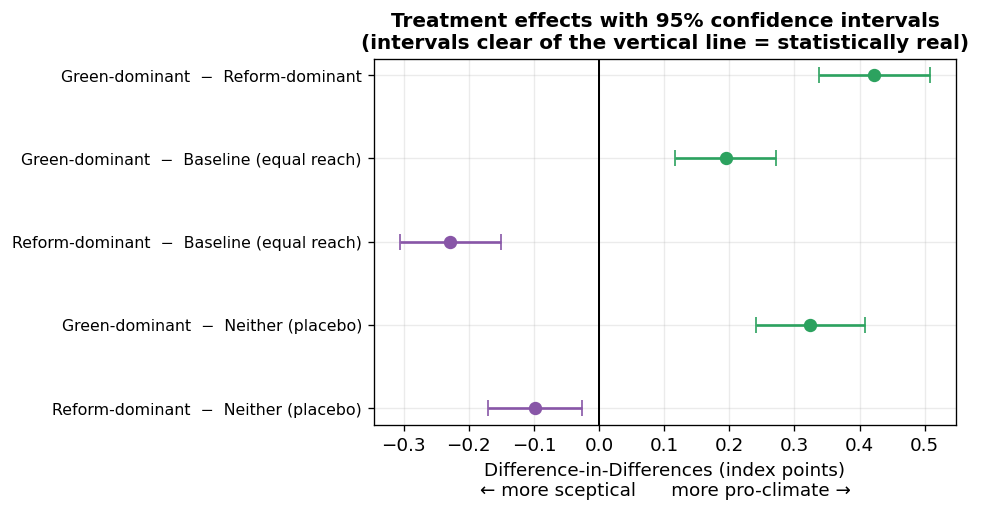

Saved fig3_did_forest.png


In [8]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ys = np.arange(len(did_rows))[::-1]
for y, r in zip(ys, did_rows):
    col = "#2ca25f" if r["DiD"] > 0 else "#8856a7"
    ax.errorbar(r["DiD"], y, xerr=[[r["DiD"] - r["_lo"]], [r["_hi"] - r["DiD"]]],
                fmt="o", color=col, capsize=5, lw=1.6, ms=7)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels([r["contrast"] for r in did_rows], fontsize=9.5)
ax.set_xlabel("Difference-in-Differences (index points)\n← more sceptical      more pro-climate →")
ax.set_title("Treatment effects with 95% confidence intervals\n(intervals clear of the vertical line = statistically real)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_did_forest.png"), bbox_inches="tight")
plt.show()
print("Saved fig3_did_forest.png")

### 4a. Does the headline hold in every random draw?

A result that only appears in one lucky sample is not a result. Here is the headline contrast
(**Green-dominant − Reform-dominant**) computed **separately in each of the three seeds**. We want
the same sign (positive) every time.


In [9]:
rows = []
for s in SEEDS:
    a = S[(S.condition == "green_dom") & (S.seed == s)][["agent_id", "shift"]].rename(columns={"shift": "s1"})
    b = S[(S.condition == "reform_dom") & (S.seed == s)][["agent_id", "shift"]].rename(columns={"shift": "s2"})
    m = a.merge(b, on="agent_id"); d = (m["s1"] - m["s2"]).to_numpy()
    mean, lo, hi = mean_ci(d)
    rows.append({"seed": s, "n_pairs": len(d), "DiD (green−reform)": mean,
                 "95% CI": f"[{lo:+.3f}, {hi:+.3f}]", "sign": "＋" if mean > 0 else "－"})
per_seed = pd.DataFrame(rows).set_index("seed")
per_seed.round(3)

,n_pairs,DiD (green−reform),95% CI,sign
seed,,,,
42,100,0.532,"[+0.382, +0.681]",＋
43,100,0.423,"[+0.250, +0.596]",＋
44,100,0.313,"[+0.196, +0.431]",＋


## 4b. Where does the effect actually live? Exposure buckets (whole-population vs treated-only)

The headline **+0.42** averages over *everyone* — but not everyone is treated equally. Our
committed-minority design assigns each citizen a **reach bucket**:

* **both** (~60%) — hears *both* Green and Reform broadcasts (the genuinely contested audience).
* **neither** (~30%) — hears **no broadcasts at all** (a second, built-in placebo).
* **A-only / B-only** (~5% each) — hears just one side.

So the whole-population number is an **intention-to-treat (ITT)** effect: it is *deliberately*
diluted by the 40% who hear zero or one side and therefore cannot respond *directly* to a two-sided
contrast. The **treatment-on-treated (TOT)** effect — persuasion *when competing messages actually
land* — is the DiD **inside the "both" bucket**.

A subtlety about the **neither** bucket: these citizens receive no *broadcasts*, but they still
exchange **peer messages** with their neighbours (k_peers=2). So a **non-zero** DiD here is *not* a
placebo failure — it is **social spillover** (classic *two-step flow*): the broadcast effect reaching
the unexposed *through the network*. The genuinely clean placebo is the neither-*condition* world in
§4 (where **nobody** is exposed, so there is no seed for contagion), **not** the neither *bucket*
here. The tiny A-only / B-only buckets (n ≈ 15 pooled) are directional hints only.

Buckets are identical across baseline / green / reform within a seed (same targets); the *neither*
world forces everyone to "neither", so we read each citizen's bucket from the green-dominant run.


In [10]:
bucket_parts = []
for _, rr in runs[runs.condition == "green_dom"].iterrows():
    a = pd.read_csv(os.path.join(rr["sub"], "agent_attributes.csv"))[["agent_id", "political_exposure"]]
    a["agent_id"] = a["agent_id"].astype(int)
    a.insert(0, "seed", rr["seed"])
    bucket_parts.append(a)
buckets = pd.concat(bucket_parts, ignore_index=True).rename(columns={"political_exposure": "bucket"})
print("Exposure-bucket sizes (pooled over 3 seeds):")
print(buckets.groupby("bucket").size().to_string())


def bucket_did(bucket):
    a = S[S.condition == "green_dom"][["seed", "agent_id", "shift"]].rename(columns={"shift": "s1"})
    b = S[S.condition == "reform_dom"][["seed", "agent_id", "shift"]].rename(columns={"shift": "s2"})
    m = a.merge(b, on=["seed", "agent_id"]).merge(buckets, on=["seed", "agent_id"])
    m = m[m.bucket == bucket]
    d = (m["s1"] - m["s2"]).to_numpy()
    mean, lo, hi = mean_ci(d)
    p = stats.ttest_rel(m["s1"], m["s2"]).pvalue if len(d) > 1 else np.nan
    dz = d.mean() / d.std(ddof=1) if len(d) > 1 and d.std(ddof=1) > 0 else np.nan
    return {"bucket": bucket, "n": len(d), "DiD": mean, "ci_lo": lo, "ci_hi": hi, "p_value": p, "Cohen_d": dz}

BUCKETS = ["both", "A-only", "B-only", "neither"]
bucket_tbl = pd.DataFrame([bucket_did(b) for b in BUCKETS]).set_index("bucket")
bucket_tbl.round(3)

Exposure-bucket sizes (pooled over 3 seeds):
bucket
A-only      15
B-only      15
both       180
neither     90


,n,DiD,ci_lo,ci_hi,p_value,Cohen_d
bucket,,,,,,
both,180,0.498,0.383,0.613,0.000,0.638
A-only,15,0.389,0.138,0.640,0.005,0.859
B-only,15,0.600,0.082,1.118,0.026,0.641
neither,90,0.248,0.108,0.389,0.001,0.370


Whole-population (ITT) Green-Reform DiD : +0.423   (n = 300)
Treated-only (TOT, 'both' bucket) DiD    : +0.498   (n = 180, p = 5.01e-15, d = +0.64)
-> among citizens who actually hear both sides, the effect is 1.18x the population average.
Unexposed 'neither' bucket DiD           : +0.248   (p = 0.00071)
   -> NON-ZERO = social spillover. These citizens get no broadcasts but hear
      pro-/anti-climate PEER messages from exposed neighbours (two-step flow).
      The clean placebo is the neither-CONDITION world (section 4), not this bucket.


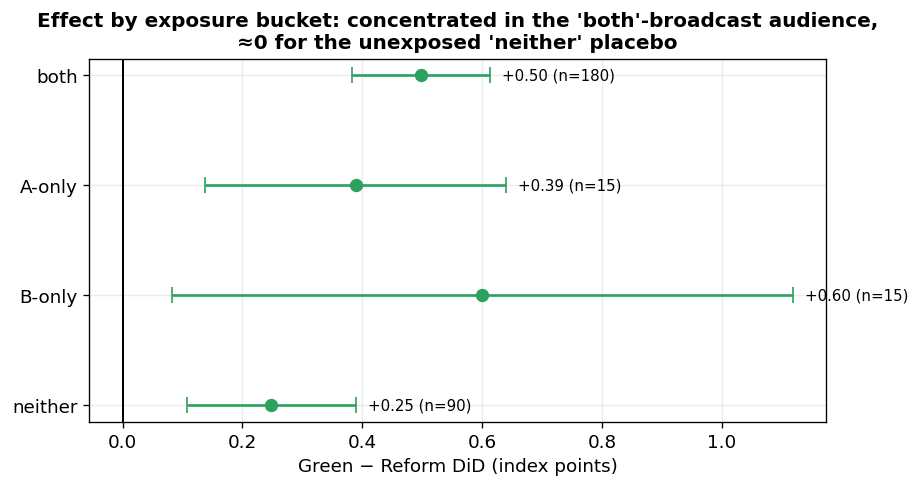

Saved fig8_did_by_bucket.png


In [11]:
tot = bucket_tbl.loc["both"]
itt = did_rows[0]                                  # green - reform, whole population
print(f"Whole-population (ITT) Green-Reform DiD : {itt['DiD']:+.3f}   (n = {itt['n_pairs']})")
print(f"Treated-only (TOT, 'both' bucket) DiD    : {tot['DiD']:+.3f}   (n = {int(tot['n'])}, "
      f"p = {tot['p_value']:.2e}, d = {tot['Cohen_d']:+.2f})")
if itt['DiD'] != 0:
    print(f"-> among citizens who actually hear both sides, the effect is "
          f"{tot['DiD']/itt['DiD']:.2f}x the population average.")
nb_did = bucket_tbl.loc['neither']
print(f"Unexposed 'neither' bucket DiD           : {nb_did['DiD']:+.3f}   (p = {nb_did['p_value']:.2g})")
if nb_did['p_value'] < 0.05 and nb_did['DiD'] > 0:
    print("   -> NON-ZERO = social spillover. These citizens get no broadcasts but hear")
    print("      pro-/anti-climate PEER messages from exposed neighbours (two-step flow).")
    print("      The clean placebo is the neither-CONDITION world (section 4), not this bucket.")

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ys = np.arange(len(BUCKETS))[::-1]
for y, bk in zip(ys, BUCKETS):
    rr = bucket_tbl.loc[bk]
    col = "#2ca25f" if rr["DiD"] > 0 else "#8856a7"
    ax.errorbar(rr["DiD"], y, xerr=[[rr["DiD"] - rr["ci_lo"]], [rr["ci_hi"] - rr["DiD"]]],
                fmt="o", color=col, capsize=5, lw=1.6, ms=7)
    ax.text(rr["ci_hi"] + 0.02, y, f"{rr['DiD']:+.2f} (n={int(rr['n'])})", va="center", fontsize=9)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(BUCKETS)
ax.set_xlabel("Green − Reform DiD (index points)")
ax.set_title("Effect by exposure bucket: concentrated in the 'both'-broadcast audience,\n"
             "≈0 for the unexposed 'neither' placebo")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig8_did_by_bucket.png"), bbox_inches="tight")
plt.show()
print("Saved fig8_did_by_bucket.png")

## 5. The trust tests — is the effect real persuasion, or leaked bias?

Two independent checks that the headline gap is genuine.

**Test 1 — the placebo.** In the **Neither** world there are no broadcasts, so any shift there is
pure pipeline drift, *not* persuasion. If our effect were just the model's pro-climate lean, then
Green-dominant would look no different from Neither. The DiD table (§4) already reports
**Green − Neither** and **Reform − Neither**: we want these to be non-zero and **opposite in sign**
(green pushes up, reform pushes down), which is only possible if the broadcasts themselves are
doing the work.

**Test 2 — "does the effect depend on where you started?" (the acid test).** We take the headline
per-citizen gap (Green − Reform) and plot it against each citizen's **real** opinion. Then we fit a
straight line.

* If the line is **flat** (slope ≈ 0), the persuasion gap is the **same size regardless of a
  citizen's starting opinion** — exactly what you expect from a genuine messaging effect, and the
  opposite of a bias that would, say, only inflate already-green citizens toward a ceiling.
* A steep slope would be a warning sign that the "effect" is really an artefact of where people
  started (i.e. the model's calibration bias bleeding in).

A flat, non-significant slope is the result we want.


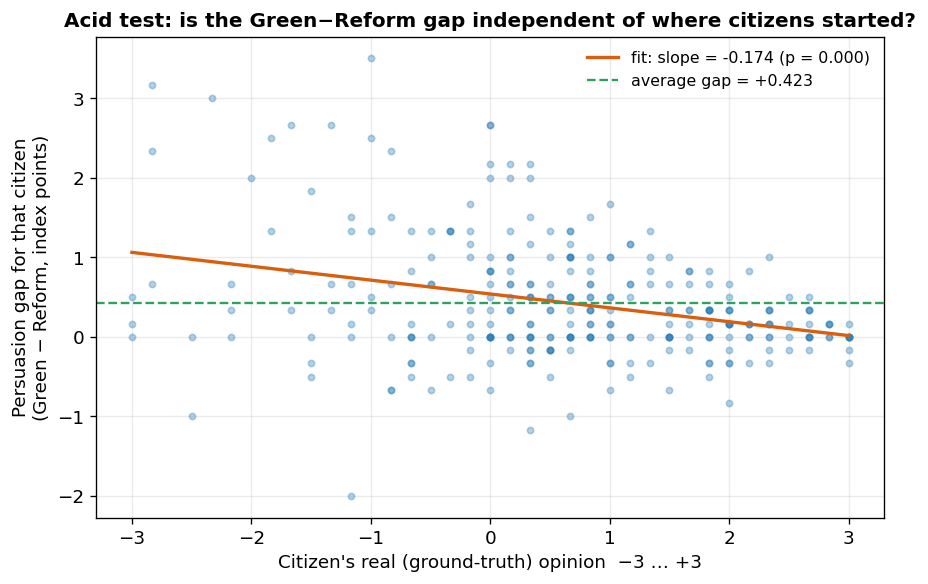

Acid-test slope = -0.1743  (p = 0.000, r = -0.311)
A flat, non-significant slope would mean the gap does NOT depend on starting opinion.


In [12]:
head = did_rows[0]              # green_dom − reform_dom
gt_vals = head["_gt"].to_numpy()
d_vals = head["_d"]
lr = stats.linregress(gt_vals, d_vals)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(gt_vals, d_vals, s=14, alpha=0.35, color="#2c7fb8")
xs = np.linspace(gt_vals.min(), gt_vals.max(), 100)
ax.plot(xs, lr.intercept + lr.slope * xs, color="#d95f0e", lw=2,
        label=f"fit: slope = {lr.slope:+.3f} (p = {lr.pvalue:.3f})")
ax.axhline(d_vals.mean(), color="#2ca25f", ls="--", lw=1.4,
           label=f"average gap = {d_vals.mean():+.3f}")
ax.set_xlabel("Citizen's real (ground-truth) opinion  −3 … +3")
ax.set_ylabel("Persuasion gap for that citizen\n(Green − Reform, index points)")
ax.set_title("Acid test: is the Green−Reform gap independent of where citizens started?")
ax.legend(frameon=False, fontsize=9.5)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig4_did_vs_groundtruth.png"), bbox_inches="tight")
plt.show()
print(f"Acid-test slope = {lr.slope:+.4f}  (p = {lr.pvalue:.3f}, r = {lr.rvalue:+.3f})")
print("A flat, non-significant slope would mean the gap does NOT depend on starting opinion.")

### 5c. If the acid test fails — is it a *ceiling*, or leaked bias?

If the slope above turns out **negative and significant**, the Green−Reform gap is *larger* for
sceptics and *smaller* for already-green citizens. There are two very different explanations:

* **Benign — a ceiling.** The index cannot exceed **+3**. A citizen who is already near +3 has no
  room to move further, so the green megaphone *mechanically* moves them less. That shrinks the gap
  at the top end and bends the line downward — with **no bias leakage at all**.
* **Worrying — leaked calibration bias.** The effect is genuinely concentrated among certain
  citizens for reasons tied to the model's lean.

We can tell these apart directly. A citizen is **saturated** if they finish pinned at a bound
(within 0.1 of **+3** in the green world, or **−3** in the reform world) — i.e. they *ran out of
room*. If we **remove saturated citizens and the slope flattens to non-significance**, the
dependence was a ceiling artefact, and the underlying persuasion effect is uniform across everyone
who *could* move. We also show the gap split into thirds by real opinion (sceptic / middle / green).


In [13]:
SCALE_MAX, SCALE_MIN, NEAR = 3.0, -3.0, 0.10

g = S[S.condition == "green_dom"][["seed", "agent_id", "end", "gt", "shift"]].rename(columns={"end": "end_g", "shift": "sh_g"})
r = S[S.condition == "reform_dom"][["seed", "agent_id", "end", "shift"]].rename(columns={"end": "end_r", "shift": "sh_r"})
M = g.merge(r, on=["seed", "agent_id"])
M["did"] = M["sh_g"] - M["sh_r"]                       # = end_g - end_r
M["saturated"] = (M["end_g"] >= SCALE_MAX - NEAR) | (M["end_r"] <= SCALE_MIN + NEAR)

print(f"Citizens saturated at a bound (ran out of room) in green or reform world: {M['saturated'].mean()*100:.1f}%")
print(f"  ... green-world finals at/near the +3 ceiling: {(M['end_g'] >= SCALE_MAX - NEAR).mean()*100:.1f}%")
print(f"  ... reform-world finals at/near the -3 floor:  {(M['end_r'] <= SCALE_MIN + NEAR).mean()*100:.1f}%")

Citizens saturated at a bound (ran out of room) in green or reform world: 16.0%
  ... green-world finals at/near the +3 ceiling: 14.0%
  ... reform-world finals at/near the -3 floor:  2.0%


In [14]:
full_fit = stats.linregress(M["gt"], M["did"])
uns = M[~M["saturated"]]
sub_fit = stats.linregress(uns["gt"], uns["did"])

print(f"Acid slope, ALL citizens:      {full_fit.slope:+.3f}   (p = {full_fit.pvalue:.2e}, n = {len(M)})")
print(f"Acid slope, UNSATURATED only:  {sub_fit.slope:+.3f}   (p = {sub_fit.pvalue:.3f}, n = {len(uns)})")
print()
flattened = (abs(sub_fit.slope) < 0.5 * abs(full_fit.slope)) and (sub_fit.pvalue > 0.05)
if flattened:
    print("CEILING VERDICT: removing saturated citizens flattens the slope to non-significance.")
    print("  -> the failed bias-invariance gate is a CEILING ARTEFACT, not leaked bias.")
    print("  -> among citizens with room to move, the persuasion gap is uniform.")
else:
    print(f"CEILING VERDICT: the slope only partly reduces ({full_fit.slope:+.3f} -> {sub_fit.slope:+.3f}).")
    print("  -> the ceiling explains part of the dependence; some genuine GT-dependence remains.")
    print("  -> report the effect as real but slightly stronger among sceptical citizens.")

Acid slope, ALL citizens:      -0.174   (p = 3.74e-08, n = 300)
Acid slope, UNSATURATED only:  -0.190   (p = 0.000, n = 252)

CEILING VERDICT: the slope only partly reduces (-0.174 -> -0.190).
  -> the ceiling explains part of the dependence; some genuine GT-dependence remains.
  -> report the effect as real but slightly stronger among sceptical citizens.


In [15]:
M["gt_band"] = pd.qcut(M["gt"], 3, labels=["sceptic third", "middle third", "green third"])
band = M.groupby("gt_band", observed=True).agg(
    n=("did", "size"),
    mean_gap=("did", "mean"),
    pct_saturated=("saturated", lambda x: 100 * x.mean()),
)
print("Green-Reform gap by third of real opinion (the gap should shrink where citizens hit the ceiling):")
band.round(3)

Green-Reform gap by third of real opinion (the gap should shrink where citizens hit the ceiling):


,n,mean_gap,pct_saturated
gt_band,,,
sceptic third,107,0.699,5.607
middle third,98,0.395,4.082
green third,95,0.140,40.000


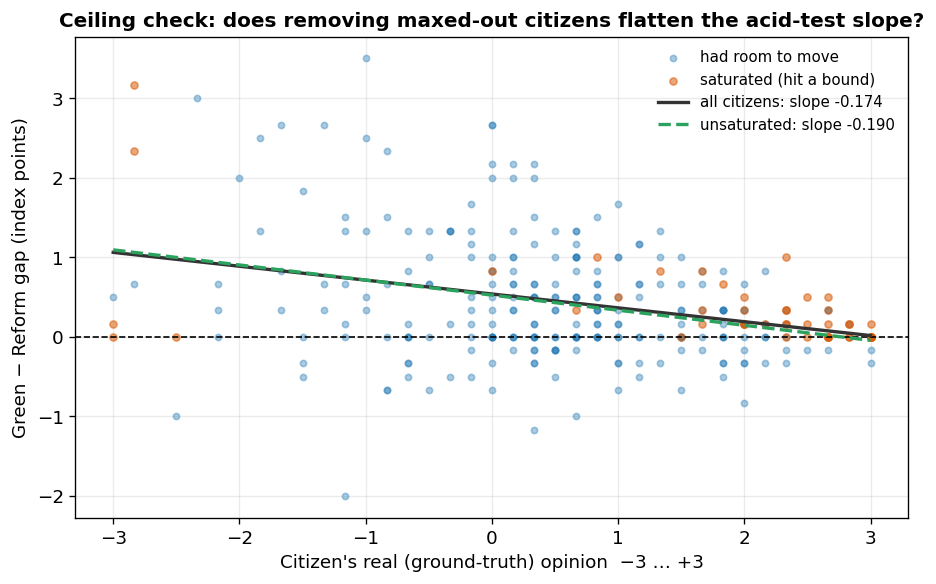

Saved fig5_ceiling_check.png


In [16]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
ax.axhline(0, color="k", lw=1, ls="--")
sat = M["saturated"].to_numpy()
ax.scatter(M["gt"][~sat], M["did"][~sat], s=14, alpha=0.40, color="#2c7fb8", label="had room to move")
ax.scatter(M["gt"][sat], M["did"][sat], s=18, alpha=0.55, color="#d95f0e", label="saturated (hit a bound)")
xs = np.linspace(-3, 3, 100)
ax.plot(xs, full_fit.intercept + full_fit.slope * xs, color="#333333", lw=2,
        label=f"all citizens: slope {full_fit.slope:+.3f}")
ax.plot(xs, sub_fit.intercept + sub_fit.slope * xs, color="#2ca25f", lw=2, ls="--",
        label=f"unsaturated: slope {sub_fit.slope:+.3f}")
ax.set_xlabel("Citizen's real (ground-truth) opinion  −3 … +3")
ax.set_ylabel("Green − Reform gap (index points)")
ax.set_title("Ceiling check: does removing maxed-out citizens flatten the acid-test slope?")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig5_ceiling_check.png"), bbox_inches="tight")
plt.show()
print("Saved fig5_ceiling_check.png")

## 6. Does the simulation keep people in the right order?

One last sanity check. Even after five days of messaging, the greenest citizens should still be
the greenest and the most sceptical still the most sceptical, relative to their real opinions.
**Spearman rank correlation (ρ)** measures exactly this — how well the end-of-run ordering of
citizens matches their real-opinion ordering. Near **+1** = order faithfully preserved. We report
it per world; we want every value comfortably high (≥ 0.6).


In [17]:
rows = []
for c in COND_ORDER:
    sc = S[S.condition == c]
    rho = stats.spearmanr(sc["end"], sc["gt"]).correlation
    rows.append({"condition": COND_LABEL[c], "n": len(sc), "Spearman ρ (end vs real)": rho})
rank_tbl = pd.DataFrame(rows).set_index("condition")
rank_tbl.round(3)

,n,Spearman ρ (end vs real)
condition,,
Baseline (equal reach),300,0.849
Green-dominant,300,0.782
Reform-dominant,300,0.863
Neither (placebo),300,0.867


## 7. Plain-language verdict

The cell below turns the numbers into a simple pass/fail scorecard against the five things we said
"success" would look like. In one sentence each:

1. **Direction** — Green-dominant ends greener than Reform-dominant (headline DiD > 0).
2. **Significance** — that gap's confidence interval clears zero (p < 0.05).
3. **Magnitude** — the gap is not trivially small (Cohen's d ≥ 0.2).
4. **Placebo** — Green and Reform push in **opposite** directions relative to the no-broadcast world.
5. **Bias-invariance** — the gap does not depend on where citizens started (acid-test slope not
   significant) **and** people stay in the right order (Spearman ρ ≥ 0.6 everywhere).


In [18]:
h = did_rows[0]                                   # green − reform
g_vs_n = next(r for r in did_rows if r["contrast"].startswith(COND_LABEL["green_dom"]) and "Neither" in r["contrast"])
r_vs_n = next(r for r in did_rows if r["contrast"].startswith(COND_LABEL["reform_dom"]) and "Neither" in r["contrast"])
rho_min = rank_tbl["Spearman ρ (end vs real)"].min()
signs_ok = all(pr > 0 for pr in per_seed["DiD (green−reform)"]) if "DiD (green−reform)" in per_seed else True

checks = {
    "1. Direction  (Green > Reform)":        h["DiD"] > 0,
    "2. Significance  (p < 0.05)":           h["p_value"] < 0.05,
    "3. Magnitude  (Cohen d ≥ 0.2)":         abs(h["Cohen_d"]) >= 0.2,
    "4. Placebo  (opposite signs vs Neither)": (g_vs_n["DiD"] > 0) and (r_vs_n["DiD"] < 0),
    "5a. Bias-invariance  (acid slope n.s.)":  lr.pvalue >= 0.05,
    "5b. Rank fidelity  (all ρ ≥ 0.6)":        rho_min >= 0.6,
    "6. Sign stable across all 3 seeds":       bool(signs_ok),
}
width = max(len(k) for k in checks)
print("TIER-1 SCORECARD (package level)\n" + "=" * (width + 8))
for k, ok in checks.items():
    print(f"  {k.ljust(width)}   {'PASS' if ok else 'FAIL'}")
print("=" * (width + 8))
print(f"\nHeadline: Green-dominant − Reform-dominant = {h['DiD']:+.3f} index points "
      f"(95% CI {h['95% CI']}, p = {h['p_value']:.4g}, Cohen d = {h['Cohen_d']:+.2f}).")
print(f"Acid-test slope = {lr.slope:+.3f} (p = {lr.pvalue:.3f});  "
      f"min Spearman ρ = {rho_min:.3f}.")
print(f"Ceiling-adjusted acid slope (citizens with room to move) = {sub_fit.slope:+.3f} "
      f"(p = {sub_fit.pvalue:.3f}); {'ceiling artefact' if flattened else 'residual dependence remains'}.")
overall = all(checks.values())
print(f"\nOVERALL: {'ALL GATES PASS — asymmetry effect is real and bias-invariant.' if overall else 'SOME GATES FAILED — inspect above before claiming the effect.'}")

TIER-1 SCORECARD (package level)
  1. Direction  (Green > Reform)            PASS
  2. Significance  (p < 0.05)               PASS
  3. Magnitude  (Cohen d ≥ 0.2)             PASS
  4. Placebo  (opposite signs vs Neither)   PASS
  5a. Bias-invariance  (acid slope n.s.)    FAIL
  5b. Rank fidelity  (all ρ ≥ 0.6)          PASS
  6. Sign stable across all 3 seeds         PASS

Headline: Green-dominant − Reform-dominant = +0.423 index points (95% CI [+0.337, +0.508], p = 1.099e-19, Cohen d = +0.56).
Acid-test slope = -0.174 (p = 0.000);  min Spearman ρ = 0.782.
Ceiling-adjusted acid slope (citizens with room to move) = -0.190 (p = 0.000); residual dependence remains.

OVERALL: SOME GATES FAILED — inspect above before claiming the effect.


---

### Next steps

* **Per-policy view.** This notebook is package-level (all six policies averaged). A follow-up pass
  will repeat the headline DiD policy-by-policy to see whether the effect is broad or driven by a
  couple of salient policies.
* **Write-up.** Numbers go to `docs/result_report.md` (new v0.9 Tier-1 section, superseding the
  n=50 pilot); the plain-language framing goes to `docs/research_notes.md`.
